# Laboratorio 8
**CC3092 – Deep Learning**

Mini-GPT a nivel de carácter sobre `tiny_shakespeare`, con estrategias de muestreo controlado (greedy, top-k, top-p) y análisis de las muestras generadas.

In [16]:
import math, random, urllib.request, os
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## Task 1.1 — Dataset, vocabulario y batches

In [17]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
if not os.path.exists("input.txt"):
    urllib.request.urlretrieve(URL, "input.txt")
text = open("input.txt", encoding="utf-8").read()
print("caracteres totales:", len(text))
print(text[:200])

caracteres totales: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [18]:
# Vocabulario de caracteres únicos y mappings bidireccionales char <-> índice
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
assert vocab_size == 65, f"se esperaban 65 caracteres, hay {vocab_size}"
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)
assert decode(encode("ROMEO:")) == "ROMEO:"
print("vocab_size =", vocab_size)
print("".join(chars).replace("\n", "\\n"))

# Texto completo -> secuencia de índices; split 90/10 respetando el orden temporal (sin shuffle)
data = torch.tensor(encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]
print("train:", len(train_data), "val:", len(val_data))

vocab_size = 65
\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
train: 1003854 val: 111540


In [19]:
# Hiperparámetros mínimos
block_size = 128
d_model    = 128
n_heads    = 4
n_layers   = 3
batch_size = 64
lr         = 3e-4
epochs     = 35   # el enunciado pide 10 como mínimo; con 10 épocas reales la perplejidad queda en ≈8.2 (subentrenado), ver Task 1.2

def get_batch(split, bs=batch_size, T=block_size):
    # x: ventana de T caracteres; y: la misma ventana desplazada 1 paso al futuro (y_t = x_{t+1}),
    # de modo que el modelo aprende P(x_{t+1} | x_{<=t}) en cada posición.
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - T - 1, (bs,))
    x = torch.stack([d[i:i + T] for i in ix])
    y = torch.stack([d[i + 1:i + T + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print(xb.shape, yb.shape, "| y es x desplazado:", bool((xb[:, 1:] == yb[:, :-1]).all()))

torch.Size([64, 128]) torch.Size([64, 128]) | y es x desplazado: True


## Mini-GPT 
Se reutiliza la implementación del `MiniGPT` de la Semana 6 (`S6 - Proyecto1_Semana6.ipynb`) con **los mismos bloques**. Utiliza parámetros crudos `nn.Parameter` (sin `nn.MultiheadAttention` ni capas de alto nivel), `layer_norm` propio, positional encoding sinusoidal de Vaswani et al., atención multi-cabeza con máscara causal (`-inf` en el triángulo superior antes del softmax), FFN con ReLU y esquema *Post-LN* (Add & LayerNorm).

**Cambios necesarios respecto a la Semana 6** (por lo que pide este laboratorio):
- Vocabulario de **caracteres** (65) en lugar de palabras de SST-2; no hay tokens `<PAD>/<BOS>/<EOS>`.
- Procesamiento por **batches** `(B, T)` en vez de una oración a la vez `(T,)`.
- **`n_layers = 3`** bloques apilados (antes 1) y `d_model=128`, `n_heads=4` (antes 32 y 2). `d_k = d_model / n_heads = 32`.
- `d_ff = 4 * d_model` (en la Semana 6 era `2 * d_model`).
- La inicialización `N(0, 0.1)` se mantiene igual que en la Semana 6.

In [20]:
def layer_norm(x, gamma, beta, eps=1e-5):
    # LayerNorm sobre la última dimensión
    #   LN(x) = gamma * (x - mean) / sqrt(var + eps) + beta
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True)
    return gamma * (x - mean) / torch.sqrt(var + eps) + beta

def make_positional_encoding(max_len, d_model):
    # Vaswani et al. 2017: PE(t,2i) = sin(t / 10000^(2i/d)),  PE(t,2i+1) = cos(t / 10000^(2i/d))
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

class GPTBlock(nn.Module):
    # Un bloque decoder-only: masked self-attention -> Add&LN -> FFN -> Add&LN (Post-LN, como en Semana 6)
    def __init__(self, d_model, d_ff, n_heads, init=0.1):
        super().__init__()
        self.n_heads, self.d_k, self.d_model = n_heads, d_model // n_heads, d_model
        P = lambda *shape: nn.Parameter(torch.randn(*shape) * init)
        self.WQ, self.WK, self.WV, self.WO = P(d_model, d_model), P(d_model, d_model), P(d_model, d_model), P(d_model, d_model)
        self.gamma1, self.beta1 = nn.Parameter(torch.ones(d_model)), nn.Parameter(torch.zeros(d_model))
        self.W1, self.bias1 = P(d_model, d_ff), nn.Parameter(torch.zeros(d_ff))
        self.W2, self.bias2 = P(d_ff, d_model), nn.Parameter(torch.zeros(d_model))
        self.gamma2, self.beta2 = nn.Parameter(torch.ones(d_model)), nn.Parameter(torch.zeros(d_model))

    def masked_self_attention(self, x, causal):
        B, T, _ = x.shape
        # Proyecciones y separación en cabezas: (B, T, d_model) -> (B, h, T, d_k)
        Q, K, V = x @ self.WQ, x @ self.WK, x @ self.WV
        Q, K, V = [t.view(B, T, self.n_heads, self.d_k).transpose(1, 2) for t in (Q, K, V)]
        # Atención escalada: scores = Q K^T / sqrt(d_k)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # Máscara causal: -inf en posiciones futuras (j > i); exp(-inf) = 0 -> atención exactamente 0 al futuro
        scores = scores.masked_fill(causal[:T, :T], float("-inf"))
        attn_w = torch.softmax(scores, dim=-1)
        out = (attn_w @ V).transpose(1, 2).contiguous().view(B, T, self.d_model)
        return out @ self.WO

    def feed_forward(self, x):
        # FFN(x) = ReLU(x W1 + b1) W2 + b2
        return torch.relu(x @ self.W1 + self.bias1) @ self.W2 + self.bias2

    def forward(self, x, causal):
        x = layer_norm(x + self.masked_self_attention(x, causal), self.gamma1, self.beta1)
        x = layer_norm(x + self.feed_forward(x), self.gamma2, self.beta2)
        return x

class MiniGPT(nn.Module):
    def __init__(self, V, d_model, d_ff, n_heads, n_layers, block_size, init=0.1):
        super().__init__()
        self.block_size = block_size
        self.E = nn.Parameter(torch.randn(V, d_model) * init)                 # embeddings de carácter
        self.register_buffer("PE", make_positional_encoding(block_size, d_model))
        # Máscara causal (triu = True = enmascarado), como CAUSAL_MASK de Semana 6
        self.register_buffer("causal", torch.triu(torch.ones(block_size, block_size), diagonal=1).bool())
        self.blocks = nn.ModuleList([GPTBlock(d_model, d_ff, n_heads, init) for _ in range(n_layers)])
        self.Wlm = nn.Parameter(torch.randn(d_model, V) * init)               # cabeza de language modeling
        self.blm = nn.Parameter(torch.zeros(V))

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.E[idx] + self.PE[:T]                                         # embedding + PE
        for blk in self.blocks:
            x = blk(x, self.causal)
        logits = x @ self.Wlm + self.blm                                      # (B, T, V): logits crudos z
        loss = None
        if targets is not None:
            # Cross-entropy L_t = -log softmax(z)[y_t], promedio sobre B*T tokens
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

model = MiniGPT(vocab_size, d_model, 4 * d_model, n_heads, n_layers, block_size).to(device)
print(f"parámetros: {sum(p.numel() for p in model.parameters()):,}")

parámetros: 609,985


In [21]:
# Verificación de causalidad: cambiar un token futuro NO debe alterar los logits de posiciones anteriores
_x = torch.randint(vocab_size, (1, 16), device=device); _x2 = _x.clone(); _x2[0, 10] = (_x2[0, 10] + 1) % vocab_size
with torch.no_grad():
    l1, _ = model(_x); l2, _ = model(_x2)
print("posiciones < 10 idénticas:", torch.allclose(l1[:, :10], l2[:, :10], atol=1e-6),
      "| posición 10 cambia:", not torch.allclose(l1[:, 10], l2[:, 10]))

posiciones < 10 idénticas: True | posición 10 cambia: True


## Task 1.2 — Entrenamiento, curvas y perplejidad de validación

**Nota sobre `epochs`:** el enunciado lista `epochs = 10` entre los hiperparámetros *mínimos*. Con 10 épocas reales (≈1,230 pasos) el modelo queda subentrenado (la perplejidad de validación es ≈8.24), fuera del rango esperado [3.5, 8.0] y la pérdida seguía bajando. Como se trata de valores mínimos, se entrena durante **35 épocas** (≈4,300 pasos); el resto de hiperparámetros no cambia. Se usa además un *warmup* lineal del learning rate (lr máximo = 3e-4).

In [ ]:
@torch.no_grad()
def evaluate_split(data_split, bs=batch_size, T=block_size):
    # Evalúa TODOS los tokens de la partición con bloques no solapados.
    # Devuelve (loss promedio por token, perplejidad). Perplejidad = exp((1/N) * sum_t L_t)
    model.eval()
    n_blocks = (len(data_split) - 1) // T
    xs = torch.stack([data_split[i * T:(i + 1) * T] for i in range(n_blocks)])
    ys = torch.stack([data_split[i * T + 1:(i + 1) * T + 1] for i in range(n_blocks)])
    total, count = 0.0, 0
    for i in range(0, n_blocks, bs):
        x, y = xs[i:i + bs].to(device), ys[i:i + bs].to(device)
        logits, _ = model(x)
        total += F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), reduction="sum").item()
        count += y.numel()
    model.train()
    mean_loss = total / count
    return mean_loss, math.exp(mean_loss)

n_train_blocks = (len(train_data) - 1) // block_size
train_xs = torch.stack([train_data[i * block_size:(i + 1) * block_size] for i in range(n_train_blocks)])
train_ys = torch.stack([train_data[i * block_size + 1:(i + 1) * block_size + 1] for i in range(n_train_blocks)])
steps_per_epoch = math.ceil(n_train_blocks / batch_size)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# Warmup lineal del learning rate (0 -> lr en los primeros pasos). El lr máximo sigue siendo 3e-4 como pide el enunciado;
# el warmup estabiliza el arranque de un Transformer Post-LN (sin él, la pérdida se queda en una meseta las primeras épocas).
warmup_steps = 150
sched = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda step: min(1.0, (step + 1) / warmup_steps))
train_losses, val_losses = [], []
print("pasos por época:", steps_per_epoch)

model.train()
for ep in range(1, epochs + 1):
    running = 0.0
    perm = torch.randperm(n_train_blocks)
    for k in range(steps_per_epoch):
        idx = perm[k * batch_size:(k + 1) * batch_size]
        x, y = train_xs[idx].to(device), train_ys[idx].to(device)
        _, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); sched.step()
        running += loss.item()
    tr = running / steps_per_epoch
    vl, vppl = evaluate_split(val_data)
    train_losses.append(tr); val_losses.append(vl)
    print(f"época {ep:2d} | train loss {tr:.4f} | val loss {vl:.4f} | val ppl {vppl:.3f}")

pasos por época: 123
época  1 | train loss 3.5888 | val loss 3.2916 | val ppl 26.886
época  2 | train loss 2.9329 | val loss 2.7008 | val ppl 14.892
época  3 | train loss 2.5965 | val loss 2.5440 | val ppl 12.731
época  4 | train loss 2.4837 | val loss 2.4433 | val ppl 11.511
época  5 | train loss 2.3800 | val loss 2.3468 | val ppl 10.452
época  6 | train loss 2.3003 | val loss 2.2935 | val ppl 9.909
época  7 | train loss 2.2363 | val loss 2.2361 | val ppl 9.357
época  8 | train loss 2.1753 | val loss 2.1852 | val ppl 8.892
época  9 | train loss 2.1257 | val loss 2.1493 | val ppl 8.579
época 10 | train loss 2.0786 | val loss 2.1094 | val ppl 8.244
época 11 | train loss 2.0337 | val loss 2.0807 | val ppl 8.010
época 12 | train loss 1.9928 | val loss 2.0570 | val ppl 7.822
época 13 | train loss 1.9568 | val loss 2.0322 | val ppl 7.631
época 14 | train loss 1.9195 | val loss 2.0160 | val ppl 7.509
época 15 | train loss 1.8892 | val loss 1.9874 | val ppl 7.297
época 16 | train loss 1.8602 

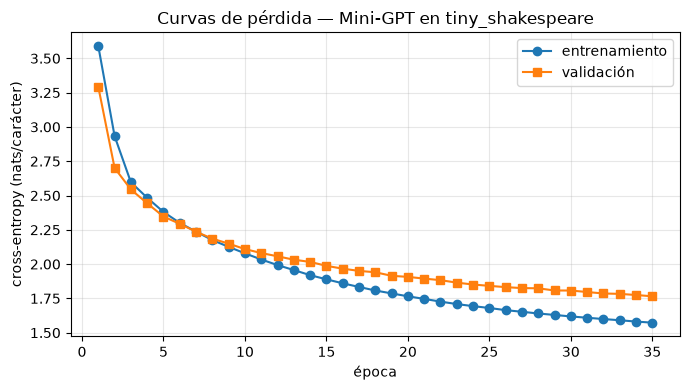

Perplejidad de validación = exp(1.7654) = 5.844
¿dentro del rango esperado [3.5, 8.0]? True


In [23]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="entrenamiento")
plt.plot(range(1, epochs + 1), val_losses, marker="s", label="validación")
plt.xlabel("época"); plt.ylabel("cross-entropy (nats/carácter)")
plt.title("Curvas de pérdida — Mini-GPT en tiny_shakespeare")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

val_loss, val_ppl = evaluate_split(val_data)
print(f"Perplejidad de validación = exp({val_loss:.4f}) = {val_ppl:.3f}")
print("¿dentro del rango esperado [3.5, 8.0]?", 3.5 <= val_ppl <= 8.0)

Queda confirmado que con los hiperparámetros elegidos la perplejidad se encuentra dentro del rango de validación y la curva de pérdida muestra que el modelo convergió. Basado en la curva, empezó a overfittear ligeramente pero probablemente dejarlo algunas épocas más con algun decay de LR dé mejores resultados.

## Task 1.3 — Funciones de muestreo (desde cero)
Las tres reciben los **logits crudos** `z` (tensor 1-D de tamaño `vocab_size`) y retornan el índice del siguiente token.

In [24]:
def sample_greedy(logits):
    # argmax_i z_i: siempre el token con mayor logit, sin aleatoriedad
    return int(torch.argmax(logits))

def sample_top_k(logits, k, tau):
    # 1) Temperatura: z_i / tau
    z = logits / tau
    # 2) Conservar solo los k logits más altos; el resto -> -inf (probabilidad 0 tras softmax)
    kth = torch.topk(z, k).values[-1]
    z = z.masked_fill(z < kth, float("-inf"))
    # 3) softmax y muestreo: P(w_i|ctx) = exp(z_i/tau) / sum_j exp(z_j/tau)
    probs = F.softmax(z, dim=-1)
    return int(torch.multinomial(probs, 1))

def sample_top_p(logits, p, tau):
    # 1) Temperatura + softmax
    probs = F.softmax(logits / tau, dim=-1)
    # 2) Ordenar de mayor a menor y acumular probabilidad
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_probs, dim=-1)
    # 3) Núcleo: tokens hasta que la acumulada supere p (se incluye el token que cruza el umbral)
    #    token j se descarta si la acumulada ANTES de él ya superaba p
    remove = (cum - sorted_probs) > p
    sorted_probs = sorted_probs.masked_fill(remove, 0.0)
    # 4) Renormalizar y muestrear
    sorted_probs = sorted_probs / sorted_probs.sum()
    choice = torch.multinomial(sorted_probs, 1)
    return int(sorted_idx[choice])

# Pruebas rápidas de sanidad
z = torch.tensor([2.0, 1.0, 0.5, -1.0, -3.0])
assert sample_greedy(z) == 0
assert all(sample_top_k(z, 2, 1.0) in (0, 1) for _ in range(200))
assert all(sample_top_p(z, 0.5, 1.0) == 0 for _ in range(200))   # softmax(z)[0] ≈ 0.57 > 0.5 -> solo el token 0
print("funciones de muestreo OK")

funciones de muestreo OK


## Task 2.1 — `generate()` y 5 muestras × 5 configuraciones

In [25]:
@torch.no_grad()
def generate(prompt, max_new_tokens, strategy, **kwargs):
    # Generación autoregresiva carácter a carácter: en cada paso se calculan los logits del
    # último carácter (contexto recortado a block_size) y se elige el siguiente con la estrategia.
    model.eval()
    ids = encode(prompt)
    for _ in range(max_new_tokens):
        ctx = torch.tensor([ids[-block_size:]], device=device)
        logits, _ = model(ctx)
        z = logits[0, -1]                       # logits crudos del siguiente carácter
        if strategy == "greedy":
            nxt = sample_greedy(z)
        elif strategy == "top-k":
            nxt = sample_top_k(z, kwargs["k"], kwargs["tau"])
        elif strategy == "top-p":
            nxt = sample_top_p(z, kwargs["p"], kwargs["tau"])
        else:
            raise ValueError(strategy)
        ids.append(nxt)
    return decode(ids)

configs = {
    "A": dict(strategy="greedy"),
    "B": dict(strategy="top-k", k=5,  tau=0.7),
    "C": dict(strategy="top-k", k=50, tau=1.0),
    "D": dict(strategy="top-p", p=0.70, tau=0.7),
    "E": dict(strategy="top-p", p=0.95, tau=1.0),
}
PROMPT, N_SAMPLES, N_CHARS = "ROMEO:", 5, 200

torch.manual_seed(SEED)
samples = {}
for name, cfg in configs.items():
    samples[name] = [generate(PROMPT, N_CHARS, **cfg) for _ in range(N_SAMPLES)]
    print("=" * 70)
    print(f"Configuración {name}: {cfg}")
    for i, s in enumerate(samples[name], 1):
        print(f"--- muestra {name}{i} ---")
        print(s)

Configuración A: {'strategy': 'greedy'}
--- muestra A1 ---
ROMEO:
Why, there the stay the see the stay the stand
That the stay the stay the stand the stay the seem
Than the stay the seem the seem the seem and the seembers
The can the seems and the seember the seemb
--- muestra A2 ---
ROMEO:
Why, there the stay the see the stay the stand
That the stay the stay the stand the stay the seem
Than the stay the seem the seem the seem and the seembers
The can the seems and the seember the seemb
--- muestra A3 ---
ROMEO:
Why, there the stay the see the stay the stand
That the stay the stay the stand the stay the seem
Than the stay the seem the seem the seem and the seembers
The can the seems and the seember the seemb
--- muestra A4 ---
ROMEO:
Why, there the stay the see the stay the stand
That the stay the stay the stand the stay the seem
Than the stay the seem the seem the seem and the seembers
The can the seems and the seember the seemb
--- muestra A5 ---
ROMEO:
Why, there the stay the see th

In [26]:
# Apoyo para 2.2c: por cada carácter generado en una muestra de la config. E, se registra la
# probabilidad máxima y el tamaño del núcleo (nº de tokens que cubren p=0.95) en ese paso.
@torch.no_grad()
def trace_top_p(prompt, n, p=0.95, tau=1.0):
    model.eval(); ids = encode(prompt); rows = []
    for _ in range(n):
        z = model(torch.tensor([ids[-block_size:]], device=device))[0][0, -1]
        probs = F.softmax(z / tau, dim=-1)
        sp, _ = torch.sort(probs, descending=True)
        nucleus = int(((torch.cumsum(sp, 0) - sp) <= p).sum())
        nxt = sample_top_p(z, p, tau)
        rows.append((decode(ids[-1:]), decode([nxt]), float(sp[0]), nucleus))
        ids.append(nxt)
    return decode(ids), rows

torch.manual_seed(SEED)
txt, rows = trace_top_p(PROMPT, N_CHARS)
print(txt, "\n")
print("Más SEGUROS (menor tamaño de núcleo, mayor prob. máx.):")
for prev, nxt, pm, nuc in sorted(rows, key=lambda r: (r[3], -r[2]))[:12]:
    print(f"  contexto ...{prev!r} -> {nxt!r}  | p_max={pm:.2f} | núcleo={nuc}")
print("Más INSEGUROS (mayor tamaño de núcleo, menor prob. máx.):")
for prev, nxt, pm, nuc in sorted(rows, key=lambda r: (-r[3], r[2]))[:12]:
    print(f"  contexto ...{prev!r} -> {nxt!r}  | p_max={pm:.2f} | núcleo={nuc}")
print(f"\nNúcleo medio: {np.mean([r[3] for r in rows]):.1f} de {vocab_size} tokens")

ROMEO:
Why label came
To childre on childing milder, my lord,
Thereing then leark thy boot of my age:
Nor meeto's neights: gart thee, crave the swet those those.
And this back nothing to thou, much me earth 

Más SEGUROS (menor tamaño de núcleo, mayor prob. máx.):
  contexto ...':' -> '\n'  | p_max=0.99 | núcleo=1
  contexto ...'s' -> 'e'  | p_max=0.99 | núcleo=1
  contexto ...'r' -> 'd'  | p_max=0.98 | núcleo=1
  contexto ...'.' -> '\n'  | p_max=0.98 | núcleo=1
  contexto ...'r' -> 'e'  | p_max=0.97 | núcleo=1
  contexto ...'n' -> 'g'  | p_max=0.97 | núcleo=1
  contexto ...'y' -> ' '  | p_max=0.96 | núcleo=1
  contexto ...'h' -> 't'  | p_max=0.96 | núcleo=1
  contexto ...'s' -> 'e'  | p_max=0.96 | núcleo=1
  contexto ...',' -> ' '  | p_max=0.95 | núcleo=1
  contexto ...'i' -> 'n'  | p_max=0.95 | núcleo=1
  contexto ...'o' -> ' '  | p_max=0.95 | núcleo=1
Más INSEGUROS (mayor tamaño de núcleo, menor prob. máx.):
  contexto ...' ' -> 'm'  | p_max=0.17 | núcleo=30
  contexto ...' ' -> 't'

## Task 2.2 — Análisis de las muestras

### 2.2 (a) — ¿Por qué greedy (config. A) repite o entra en ciclos?

Greedy elige $w_{t+1}=\arg\max_i z_i$. Es decir, es una función determinista que dado el mismo contexto siempre produce el mismo carácter y descarta completamente el resto. El comportamiento repetitivo se puede observar en las 5 muestras idénticas (al ser determinista) que caen en un ciclo de repeticiones de "the stay", "the see", "the stand".

"Why, there the stay the see the stay the stand
That the stay the stay the stand the stay the seem
Than the stay the seem the seem the seem and the seembers
The can the seems and the seember the seemb"

Esto ocurre porque, aunque en muchas posiciones la distribución del siguiente carácter está repartida entre varias opciones plausibles, greedy descarta toda esa masa y se queda siempre con la opción más probable dado el contexto. Esta suele ser una continuación muy común, por ejemplo, palabras funcionales como `the`. Al ser determinista, basta con que el contexto llegue a un estado donde el `argmax` lleve de vuelta a una secuencia ya vista para que el texto caiga en un ciclo.

### 2.2 (b) — Config. B (top-k, $k=5$, $\tau=0.7$) vs. C (top-k, $k=50$, $\tau=1.0$)

Con temperatura, la probabilidad de cada carácter es

$$P(w_i \mid ctx) = \frac{\exp(z_i/\tau)}{\sum_j \exp(z_j/\tau)}$$

En top-k, la suma del denominador solo incluye los $k$ caracteres con mayor logit. El resto tiene probabilidad 0.

El parámetro $k$ fija cuántos caracteres pueden muestrearse en cada paso. Con $k=5$ el modelo solo elige entre los cinco más probables, así que casi todo lo que genera son palabras reales y frecuentes. Por ejemplo, B1 produce "The dearst heart the the see haven one, And she when with a him." A cambio, el texto repite mucho las palabras funcionales, como "the the", "to to" o "and and". Con $k=50$ casi no hay recorte, ya que el vocabulario tiene 65 caracteres. Entran caracteres poco probables y el texto se vuelve más variado pero también más ruidoso. Aparecen palabras inventadas como "holand thany firg blains" en C1 o "Thin swrods seepil" en C5, y también más signos de puntuación.

La temperatura divide los logits antes del softmax, así que cambia qué tan separadas quedan las probabilidades. Si dos caracteres tienen logits que difieren en 1, el ratio entre sus probabilidades es $e^{1/\tau}$. Con $\tau=1.0$ ese ratio es $e^{1} \approx 2.7$, y con $\tau=0.7$ es $e^{1/0.7} \approx 4.2$. Es decir, con $\tau=0.7$ el carácter más probable gana todavía más peso frente a los demás y la distribución se concentra. Con $\tau=1.0$ se usa la distribución original del modelo, que es más plana y le da más peso a las opciones poco probables.

Hay una limitación importante. B y C cambian ambos parámetros a la vez, así que estas muestras no permiten aislar el efecto de $k$ y el de $\tau$ por separado. Lo que se observa es consistente con lo que predice la fórmula, pero no lo prueba por sí solo.

En cuanto a coherencia y creatividad, B es la más coherente a nivel de palabras, porque casi todas existen en inglés. Esto tiene sentido porque los cinco caracteres más probables suelen ser continuaciones razonables, mientras que el carácter número 30 o 50 casi nunca lo es. En C cada uno de esos caracteres tiene probabilidad baja, pero juntos suman una masa que no es despreciable, sobre todo con $\tau=1.0$. A lo largo de 200 caracteres es casi seguro que en algún momento se elija uno de ellos, y basta un solo carácter malo para romper una palabra. Además, ese error queda en el contexto y afecta las predicciones siguientes. Por eso C es la más diversa y creativa, pero produce muchas pseudo-palabras. B en cambio, no forma frases con sentido y es repetitiva, porque siempre se mueve entre las mismas opciones seguras.

### 2.2 (c) — Config. E (top-p$=0.95$, $\tau=1.0$): momentos de seguridad e incertidumbre

El tamaño del núcleo depende de la forma de la distribución en cada paso. Si el modelo está seguro, un solo carácter puede acumular casi toda la probabilidad y el núcleo es muy pequeño. Si está inseguro, la probabilidad está repartida y hacen falta muchos caracteres para llegar a 0.95.

Para respaldar esto con datos, la celda anterior genera una muestra adicional con la configuración E y registra en cada paso la probabilidad máxima $p_{\max}$ y el tamaño del núcleo. Los números se refieren a esa muestra y no a E1 a E5, pero el mismo comportamiento se ve en las cinco muestras.

El modelo está muy seguro en posiciones de puntuación, formato y continuaciones obvias de palabra. En todos estos casos el núcleo tiene un solo carácter. Después de los dos puntos que cierran el nombre de un personaje, el siguiente carácter es un salto de línea con $p_{\max}=0.99$. Esto se ve en todas las muestras, donde nombres como "RARCHIS:", "MARDIUS:" o "KING RICHARD II:" siempre van seguidos de un salto de línea. Algo parecido pasa después de un punto, donde viene un salto de línea con $p_{\max}=0.98$, y después de una coma o al final de una palabra, donde viene un espacio con $p_{\max}$ entre 0.95 y 0.96. También hay continuaciones casi forzadas dentro de las palabras. Después de una "i" el modelo elige "n" con $p_{\max}=0.95$, y después de una "n" elige "g" con $p_{\max}=0.97$. Esto es consistente con la terminación "-ing", que es muy frecuente en el corpus y que el modelo incluso aplica a palabras inventadas como "Thereing" o "childing". En todos estos casos el corpus es casi determinista, así que la distribución se concentra en una sola opción.

El modelo está inseguro en las fronteras de palabra y de línea. Los casos más inciertos son casi todos la primera letra de una palabra, justo después de un espacio. Ahí el núcleo tiene entre 24 y 30 de 65 caracteres y $p_{\max}$ está entre 0.12 y 0.23, porque elegir qué palabra viene es una decisión muy abierta. Al empezar una línea nueva pasa algo parecido, con un núcleo de 24 caracteres y $p_{\max}$ entre 0.21 y 0.31. El modelo no sabe qué personaje o qué palabra abre la línea, y es justo ahí donde aparecen los nombres inventados de las muestras, como "RARCHIS" o "KICHARD ING HERMARD III". Una vez que la palabra empezó, las opciones se reducen y la incertidumbre baja.

En total, el núcleo tuvo en promedio unos 9.1 caracteres, con valores entre 1 y 30. Esto muestra la adaptatividad que describe el enunciado. Un top-k fijo usaría siempre el mismo número de candidatos, mientras que top-p usa uno solo cuando el modelo está seguro y hasta 30 cuando no lo está.

# Entrega final

## Task 3.1 — Embeddings contextuales de `bert-base-multilingual-cased`
Para cada oración se toma el estado oculto de la **última capa** (`last_hidden_state`, dimensión 768) en la posición de la palabra objetivo (no `[CLS]`). Si WordPiece parte la palabra en varios sub-tokens, se promedian sus vectores; si es un solo token, es directamente ese vector. La posición se localiza con `offset_mapping` (caracteres de la palabra en la oración), no buscando el texto del token, para no confundirla con otras apariciones.

In [27]:
from transformers import AutoTokenizer, AutoModel
import re, pandas as pd, itertools
from sklearn.decomposition import PCA

# (oración, palabra objetivo, significado). El significado se usa solo para etiquetar tablas y colores de la visualización.
SENTENCES = [
    ("El banco central anunció una subida de tasas de interés.",          "banco", "banco (institución financiera)"),
    ("Me senté en el banco del parque a leer el periódico.",              "banco", "banco (asiento)"),
    ("El banco de peces se movió velozmente ante el tiburón.",            "banco", "banco (cardumen)"),
    ("El equipo levantó la copa del torneo ante miles de aficionados.",   "copa",  "copa (trofeo)"),
    ("Sirvió una copa de vino tinto para acompañar la cena.",             "copa",  "copa (recipiente)"),
    ("El velero desplegó su vela para aprovechar el viento.",             "vela",  "vela (de barco)"),
    ("Encendió una vela para iluminar el cuarto durante el apagón.",      "vela",  "vela (cirio)"),
]

bert_name = "bert-base-multilingual-cased"
tok  = AutoTokenizer.from_pretrained(bert_name)
bert = AutoModel.from_pretrained(bert_name).to(device).eval()

@torch.no_grad()
def target_embedding(sentence, word):
    # Rango de caracteres de la palabra objetivo (palabra completa, primera aparición).
    m = re.search(rf"\b{re.escape(word)}\b", sentence)
    start, end = m.start(), m.end()
    enc = tok(sentence, return_offsets_mapping=True, return_tensors="pt")
    offsets = enc.pop("offset_mapping")[0]
    # Sub-tokens cuyo rango de caracteres cae dentro de la palabra ([CLS]/[SEP] tienen offset (0,0) y se excluyen).
    idx = [i for i, (s, e) in enumerate(offsets.tolist()) if e > s and s >= start and e <= end]
    assert idx, f"no se encontró '{word}' en los tokens"
    h = bert(**{k: v.to(device) for k, v in enc.items()}).last_hidden_state[0]   # (T, 768)
    tokens = tok.convert_ids_to_tokens(enc["input_ids"][0])
    return h[idx].mean(0).cpu(), [tokens[i] for i in idx]

bert_emb = []
for sent, word, sense in SENTENCES:
    e, toks = target_embedding(sent, word)
    bert_emb.append(e)
    print(f"{sense:32s} sub-tokens usados: {toks} | dim = {tuple(e.shape)}")
bert_emb = torch.stack(bert_emb)   # (7, 768)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


banco (institución financiera)   sub-tokens usados: ['banco'] | dim = (768,)
banco (asiento)                  sub-tokens usados: ['banco'] | dim = (768,)
banco (cardumen)                 sub-tokens usados: ['banco'] | dim = (768,)
copa (trofeo)                    sub-tokens usados: ['copa'] | dim = (768,)
copa (recipiente)                sub-tokens usados: ['copa'] | dim = (768,)
vela (de barco)                  sub-tokens usados: ['vela'] | dim = (768,)
vela (cirio)                     sub-tokens usados: ['vela'] | dim = (768,)


## Task 3.2 — Similitud coseno, Word2Vec y PCA
### (a) Similitud coseno entre contextos distintos de la misma palabra (BERT)
$$\text{sim}(\mathbf{u},\mathbf{v}) = \frac{\mathbf{u}^\top \mathbf{v}}{\lVert\mathbf{u}\rVert\,\lVert\mathbf{v}\rVert}$$
Se calcula para todos los pares (i, j), i < j, de oraciones con la misma palabra objetivo: 3 pares para *banco*, 1 para *copa* y 1 para *vela*.

In [ ]:
def cosine(u, v):
    # Similitud coseno
    return float(u @ v / (u.norm() * v.norm()))

rows = []
for word in ["banco", "copa", "vela"]:
    ids = [i for i, (_, w, _) in enumerate(SENTENCES) if w == word]
    for i, j in itertools.combinations(ids, 2):
        rows.append({"palabra": word,
                     "contexto 1": SENTENCES[i][2], "contexto 2": SENTENCES[j][2],
                     "cos BERT": cosine(bert_emb[i], bert_emb[j])})
bert_table = pd.DataFrame(rows)
bert_table

,palabra,contexto 1,contexto 2,cos BERT
0,banco,banco (institución financiera),banco (asiento),0.575264
1,banco,banco (institución financiera),banco (cardumen),0.660292
2,banco,banco (asiento),banco (cardumen),0.649650
3,copa,copa (trofeo),copa (recipiente),0.566662
4,vela,vela (de barco),vela (cirio),0.799936


### (b) Vectores estáticos Word2Vec y comparación con BERT
El descargador de gensim no incluye modelos en español, así que se carga desde el Hub de HuggingFace `Word2vec/wikipedia2vec_eswiki_20180420_300d` (vectores de 300 dimensiones tipo skip-gram entrenados sobre Wikipedia en español, formato Word2Vec de texto) con `gensim.models.KeyedVectors`. Un modelo estático asigna **un único vector por palabra**, sin importar la oración, por lo que la similitud entre dos contextos de la misma palabra es 1.0 por construcción. Esto no es un hallazgo empírico; es justamente la limitación que BERT corrige.

In [29]:
from huggingface_hub import hf_hub_download
from gensim.models import KeyedVectors

# Word2Vec en español (Wikipedia, 300 d). La primera vez descarga el archivo de texto (~3 GB).
w2v_path = hf_hub_download("Word2vec/wikipedia2vec_eswiki_20180420_300d", "eswiki_20180420_300d.txt")
w2v = KeyedVectors.load_word2vec_format(w2v_path, binary=False)

static = {w: torch.tensor(w2v[w]) for w in ["banco", "copa", "vela"]}
for w in static:
    print(f"{w}: dim = {static[w].shape[0]} | vecinos más cercanos: {[n for n, _ in w2v.most_similar(w, topn=6)]}")

bert_table["cos Word2Vec"] = [
    cosine(static[r.palabra], static[r.palabra]) for r in bert_table.itertuples()   # mismo vector -> 1.0
]
bert_table["BERT - Word2Vec"] = bert_table["cos BERT"] - bert_table["cos Word2Vec"]
bert_table.round(4)

banco: dim = 300 | vecinos más cercanos: ['hipotecario', 'sudameris', 'bancos', 'totalbank', 'finantia', 'banex']
copa: dim = 300 | vecinos más cercanos: ['supercopa', 'recopa', 'copas', 'redireccióncopa', 'libertadores', 'cup']
vela: dim = 300 | vecinos más cercanos: ['enverga', 'envergada', 'rfev', 'envergar', 'gennaker', 'contromano']


,palabra,contexto 1,contexto 2,cos BERT,cos Word2Vec,BERT - Word2Vec
0,banco,banco (institución financiera),banco (asiento),0.5753,1.0,-0.4247
1,banco,banco (institución financiera),banco (cardumen),0.6603,1.0,-0.3397
2,banco,banco (asiento),banco (cardumen),0.6496,1.0,-0.3504
3,copa,copa (trofeo),copa (recipiente),0.5667,1.0,-0.4333
4,vela,vela (de barco),vela (cirio),0.7999,1.0,-0.2001


Con Word2Vec la similitud es 1.0 en todos los pares, esto es una consecuencia de cómo funciona el modelo. Word2Vec es estático y guarda un solo vector por palabra, así que "banco" tiene el mismo vector sin importar la oración en la que aparece. No puede distinguir entre diferentes sentidos semánticos.

Los vecinos más cercanos muestran qué sentido domina ese vector. Para "banco" son "hipotecario", "bancos" o "banex", todos del sentido financiero. Para "copa" son "supercopa", "recopa" o "libertadores", del sentido de trofeo. Para "vela" son términos de navegación como "envergadura" o "gennaker". Como el vector se aprende de todas las apariciones de la palabra en Wikipedia, queda dominado por el sentido más frecuente. Los sentidos menos comunes, como banco de asiento o vela de cirio, casi no se reflejan.

BERT, en cambio, sí separa los sentidos. Sus similitudes van de 0.57 a 0.80, claramente por debajo de 1, porque cada vector depende de la oración completa. El par con mayor similitud es el de "vela" con 0.80, lo que sugiere que BERT separó menos esos dos sentidos. Aun así, como hay una sola oración por sentido las diferencias pequeñas entre pares pueden deberse a las oraciones específicas y no tanto al sentido. Se deberían de analizar más oraciones utilizando cada una de las palabras en sus diferentes sentidos.

### (c) Visualización con PCA (2D) de los embeddings de BERT
Cada punto es una instancia de la palabra en su contexto (7 en total). El color indica el significado y la forma indica la palabra. El PCA se ajusta sobre las 7 instancias juntas.

varianza explicada por PC1, PC2: [0.35  0.235]


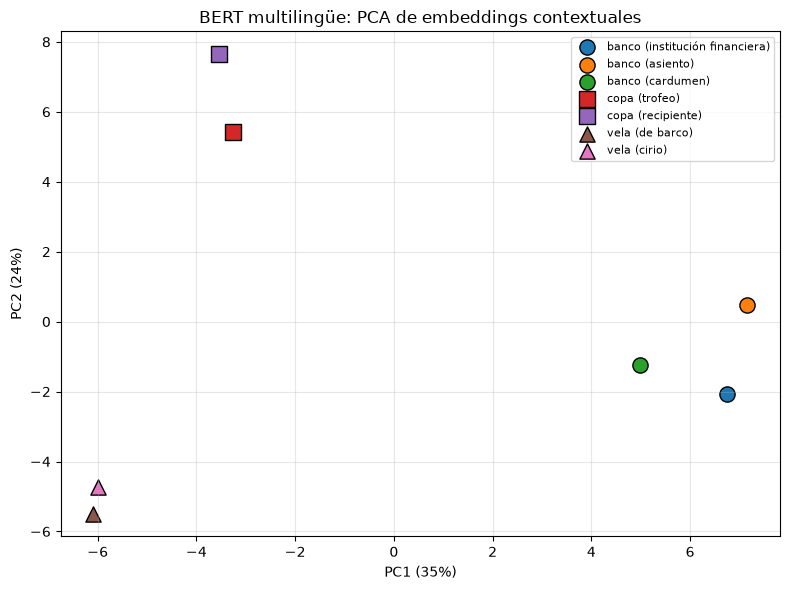

In [30]:
pca = PCA(n_components=2)
Z = pca.fit_transform(bert_emb.numpy())
print("varianza explicada por PC1, PC2:", pca.explained_variance_ratio_.round(3))

senses  = [s for _, _, s in SENTENCES]
colors  = dict(zip(senses, plt.cm.tab10.colors[:len(senses)]))
markers = {"banco": "o", "copa": "s", "vela": "^"}
plt.figure(figsize=(8, 6))
for (sent, word, sense), (x, y) in zip(SENTENCES, Z):
    plt.scatter(x, y, s=120, color=colors[sense], marker=markers[word], label=sense, edgecolor="k")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})"); plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
plt.title("BERT multilingüe: PCA de embeddings contextuales"); plt.grid(alpha=.3)
plt.legend(fontsize=8, loc="best"); plt.tight_layout(); plt.show()

En la proyección PCA los puntos se agrupan por palabra y no por significado. Se forman tres grupos claros:

- Los tres "banco" a la derecha
- Los dos "copa" arriba a la izquierda
- Los dos "vela" abajo a la izquierda. 

Dentro de cada grupo los distintos sentidos aparecen como puntos separados, así que BERT sí les asigna vectores diferentes. Sin embargo, la distancia entre sentidos de una misma palabra es mucho menor que la distancia entre palabras distintas. Es decir, la mayor fuente de variación en el espacio es qué palabra es, y el contexto solo la desplaza un poco dentro de su grupo.

Esto es consistente con las similitudes coseno de la tabla anterior. Los dos sentidos de "vela" quedan casi encima uno del otro, lo que coincide con su similitud de 0.80. En "banco", el sentido de asiento queda algo apartado de los otros dos y es justo el par con menor similitud frente al sentido financiero. La visualización en dos dimensiones puede no ser la comparación más precisa, pero si podemos concluir que los contextos distintos sí se separan, pero dentro del espacio de la palabra y no como grupos independientes por significado.

## Task 4.1 — Preguntas conceptuales

### (a) Máscara causal y atención bidireccional

El objetivo de language modeling factoriza la probabilidad de una secuencia como

$$P(x_1,\dots,x_T)=\prod_t P(x_t\mid x_{<t})$$

Para que el modelo estime $P(x_t\mid x_{<t})$, la representación en la posición $t$ solo puede depender de los tokens anteriores. La máscara causal logra esto sumando $-\infty$ a los scores de atención con $j>i$ antes del softmax, así que esos pesos quedan exactamente en 0. Esto es necesario porque en el entrenamiento todas las posiciones se calculan en paralelo con teacher forcing. Sin la máscara, la posición $t$ podría ver el token $x_{t+1}$, que es su etiqueta.

Si GPT usara atención bidireccional en el preentrenamiento, predecir el siguiente token se volvería trivial. El modelo aprendería a copiar $x_{t+1}$ desde la entrada y la pérdida caería casi a 0 sin que aprendiera mucho sobre el lenguaje. Además, el modelo ya no definiría una distribución $P(x_t\mid x_{<t})$ válida. El problema aparece en la generación, porque ahí el siguiente token todavía no existe. Lo que el modelo aprendió a hacer ya no sirve y hay una discrepancia entre cómo se entrenó y cómo se usa.

### (b) Preentrenar y adaptar: GPT vs. BERT

En el Task 3, BERT dio vectores distintos para la misma palabra en contextos distintos con similitudes coseno entre 0.57 y 0.80, mientras que Word2Vec dio 1.0 en todos los casos. Esto pasa porque BERT calcula cada token atendiendo a la oración completa, tanto a la izquierda como a la derecha. Esa propiedad es útil para tareas de comprensión, como clasificación, desambiguación, similitud o extracción de entidades. GPT con atención causal, solo ha visto el contexto anterior cuando llega a "banco". Su representación en ese punto no puede usar lo que viene después como "del parque" o "de peces", que es justo lo que define el sentido. A cambio, GPT sí define $P(x_t\mid x_{<t})$ y puede generar texto, como hicimos en el Task 2.

El paradigma de preentrenar y adaptar resuelve esta tensión porque ambos modelos ya fueron preentrenados con grandes corpus. No hace falta entrenar ninguno desde cero, solo elegir el adecuado para la tarea. Si la tarea es entender o clasificar texto, se usa BERT y se le agrega una capa pequeña o se hace fine-tuning, partiendo de embeddings como los del Task 3. Si la tarea es generar o continuar texto, se usa GPT con prompting o fine-tuning. El costo grande de aprender el lenguaje se paga una sola vez en el preentrenamiento, y la adaptación a cada tarea es barata.

Nuestros resultados también muestran por qué la adaptación importa. La separación de significados en BERT fue parcial. Los dos sentidos de "vela" tuvieron una similitud de 0.80, y en el PCA los puntos se agruparon por palabra y no por significado. Por eso, para una desambiguación fina conviene hacer fine-tuning en lugar de usar los embeddings congelados tal cual.